In [530]:
import csv
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Reshape, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from IPython.display import Image
import PIL

In [531]:
# Step 1: Load data from CSV file and preprocess
x = []
y = []

with open("data_new.csv", "r") as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=",")
    convert_rgb = lambda color: tuple(int(color[i:i+2], 16) for i in (0,2,4))
    for row in csv_reader:
        x.append(convert_rgb(row[0]))
        y.append([convert_rgb(x) for x in row[1].split(" ")])
        
train_x = np.array(x) / 255.0
train_y = np.array(y) / 255.0

In [532]:
train_x[0].shape

(3,)

In [533]:
model = Sequential([
    Dense(units='64', activation='relu', input_shape=(3,)),
    Dropout(0.2),
    Dense(units='128', activation='relu'),
    Dropout(0.2),
    Dense(units='256', activation='relu'),
    Dropout(0.2),
    Dense(units='512', activation='relu'),
    Dropout(0.2),
    Dense(units='1024', activation='relu'),
    Dropout(0.2),
    Dense(9, activation='linear'),
    Reshape((3, 3))
])

In [526]:
#Old model.

# model = Sequential([
#     Dense(units='64', activation='relu', input_shape=(3,)),
#     Dropout(0.2),
#     Dense(units='128', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
#     Dropout(0.2),
#     Dense(units='256', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
#     Dropout(0.2),
#     Dense(units='512', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
#     Dropout(0.2),
#     Dense(units='1024', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
#     Dropout(0.2),
#     Dense(units='2048', activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
#     Dense(9, activation='linear'),
#     Reshape((3, 3))
# ])

In [535]:
model.summary()

Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_107 (Dense)           (None, 64)                256       
                                                                 
 dropout_40 (Dropout)        (None, 64)                0         
                                                                 
 dense_108 (Dense)           (None, 128)               8320      
                                                                 
 dropout_41 (Dropout)        (None, 128)               0         
                                                                 
 dense_109 (Dense)           (None, 256)               33024     
                                                                 
 dropout_42 (Dropout)        (None, 256)               0         
                                                                 
 dense_110 (Dense)           (None, 512)             

In [536]:
model.compile(optimizer="adam", loss="mse")

In [537]:
model.fit(train_x, train_y, epochs=50, batch_size=32)

Epoch 1/50
104/104 [==============================] - 1s 6ms/step - loss: 0.0980
Epoch 2/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0744
Epoch 3/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0714
Epoch 4/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0702
Epoch 5/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0695
Epoch 6/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0689
Epoch 7/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0687
Epoch 8/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0683
Epoch 9/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0677
Epoch 10/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0679
Epoch 11/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0674
Epoch 12/50
104/104 [==============================] - 1s 5ms/step - loss: 0.0675
Epoch 13/50
104/104 [====

In [542]:
test_color = [178,66,255]
test_x = np.array([test_color]) / 255.0

In [546]:
res = model.predict(test_x) * 255.0

1/1 [==============================] - 0s 17ms/step


In [547]:
c1 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(test_color))
c2 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res[0][0]))
c3 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res[0][1]))
c4 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res[0][2]))

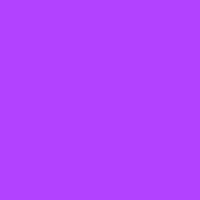

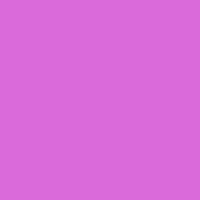

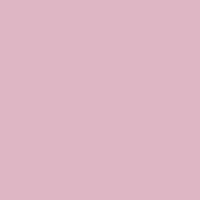

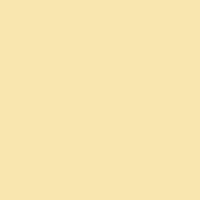

In [545]:
display(c1)
display(c2)
display(c3)
display(c4)

In [441]:
#Useless Testing...

def create_pallette(color):
    test_x = np.array([color]) / 255.0
    res = model.predict(test_x) * 255.0
    next_input = np.array([res[0][0]]) / 255.0
    res_next = model.predict(next_input) * 255.0
    next_input_2 = np.array([res_next[0][0]]) / 255.0
    res_next_2 = model.predict(next_input_2) * 255.0
    c1 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(color))
    c2 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res[0][0]))
    c3 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res_next[0][0]))
    c4 = PIL.Image.new(mode="RGB", size=(200,200), color = tuple(int(x) for x in res_next_2[0][0]))
    display(c1)
    display(c2)
    display(c3)
    display(c4)

1/1 [==============================] - 0s 20ms/step


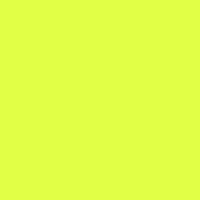

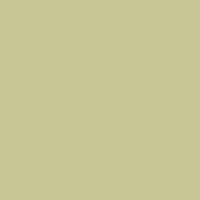

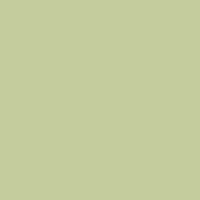

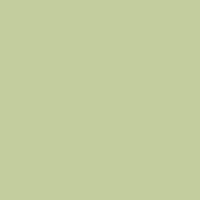

In [443]:
create_pallette([225,255,70])